## Importing basic libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Importing dataset

In [2]:
df=pd.read_csv('Learner_Opportunity.csv')
df.head()

,enrollment_id,learner_id,assigned_cohort,apply_date,status
0,Learner#4e6f78a9-f9b2-4352-ad22-d43dc46f5ff7,Opportunity#0000000010WCBS50CYGDX97ES4,BAM6HBR,2024-04-10T06:28:31.902Z,1070.0
1,Learner#4e79d245-3436-4fec-9906-901a03639ad1,Opportunity#0000000010WCBS50CYGDX97ES4,BAM6HBR,2023-11-15T03:08:17.442Z,1120.0
2,Learner#4e9f5cb5-0576-4dbc-b7f5-1fae5f29b2df,Opportunity#0000000010WCBS50CYGDX97ES4,BAM6HBR,2024-04-06T14:07:01.322Z,1070.0
3,Learner#4ea61aa9-17da-4b60-9872-359b8e1e1635,Opportunity#0000000010WCBS50CYGDX97ES4,BT4YTCR,2024-04-11T22:01:13.548Z,1070.0
4,Learner#4eb218c7-467a-470a-9e3e-a2b7bc649e18,Opportunity#0000000010WCBS50CYGDX97ES4,BT4YTCR,2024-10-22T15:44:13.402Z,1120.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113602 entries, 0 to 113601
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   enrollment_id    113602 non-null  object 
 1   learner_id       113602 non-null  object 
 2   assigned_cohort  100284 non-null  object 
 3   apply_date       113414 non-null  object 
 4   status           113416 non-null  float64
dtypes: float64(1), object(4)
memory usage: 4.3+ MB


# Converting the apply_date column dtype to datetime

In [4]:
df['apply_date'] = pd.to_datetime(df['apply_date'], errors='coerce', utc=True)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113602 entries, 0 to 113601
Data columns (total 5 columns):
 #   Column           Non-Null Count   Dtype              
---  ------           --------------   -----              
 0   enrollment_id    113602 non-null  object             
 1   learner_id       113602 non-null  object             
 2   assigned_cohort  100284 non-null  object             
 3   apply_date       113414 non-null  datetime64[ns, UTC]
 4   status           113416 non-null  float64            
dtypes: datetime64[ns, UTC](1), float64(1), object(3)
memory usage: 4.3+ MB


## Identify Categorical & Numerical Columns

In [6]:
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_col = df.select_dtypes(include=['float64']).columns

print("Categorical columns:", list(categorical_cols))
print("Numerical column:", list(numerical_col))

Categorical columns: ['enrollment_id', 'learner_id', 'assigned_cohort']
Numerical column: ['status']


## Count of rows and columns

In [7]:
rows, columns = df.shape
print("Total rows:", rows)
print("Total columns:", columns)

Total rows: 113602
Total columns: 5


## checking for Duplicate records

In [8]:
df[df.duplicated()]

,enrollment_id,learner_id,assigned_cohort,apply_date,status


# insights and observation
no duplicates found

## Checking for null values

In [9]:
df.isnull().sum()

enrollment_id          0
learner_id             0
assigned_cohort    13318
apply_date           188
status               186
dtype: int64

# insights and observation
found some missing values in the 3 of 5 columns

## handling missing data

In [10]:
# Replace missing categorical values of assigned_cohort column with 'Unknown'
df['assigned_cohort'] = df['assigned_cohort'].fillna('Unknown')
print(df)

                                       enrollment_id  \
0       Learner#4e6f78a9-f9b2-4352-ad22-d43dc46f5ff7   
1       Learner#4e79d245-3436-4fec-9906-901a03639ad1   
2       Learner#4e9f5cb5-0576-4dbc-b7f5-1fae5f29b2df   
3       Learner#4ea61aa9-17da-4b60-9872-359b8e1e1635   
4       Learner#4eb218c7-467a-470a-9e3e-a2b7bc649e18   
...                                              ...   
113597  Learner#8f5846ca-22c5-43ff-a2d9-16781e5375c6   
113598  Learner#8f5867ac-a5d6-408c-87c8-d3d4799b52a2   
113599  Learner#8f636278-8c8c-43f9-a8fd-f06f706224ef   
113600  Learner#8f6e5b4e-22b1-4bbf-a8ff-8377773efb81   
113601  Learner#8f71095a-ebe7-41f0-a1a6-5aabc35c322e   

                                    learner_id assigned_cohort  \
0       Opportunity#0000000010WCBS50CYGDX97ES4         BAM6HBR   
1       Opportunity#0000000010WCBS50CYGDX97ES4         BAM6HBR   
2       Opportunity#0000000010WCBS50CYGDX97ES4         BAM6HBR   
3       Opportunity#0000000010WCBS50CYGDX97ES4         BT4YTCR 

In [11]:
df.assigned_cohort.isnull().sum()

0

In [12]:
# Handle missing apply_data column data with forward fill
df['apply_date'] = df['apply_date'].fillna(method='ffill')
df.apply_date.isnull().sum()

C:\Users\user\AppData\Local\Temp\ipykernel_25124\3019329781.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['apply_date'] = df['apply_date'].fillna(method='ffill')


0

In [13]:
# Handle missing apply_data column data with mean
df['status'] = df['status'].fillna(df['status'].mean())
df.status.isnull().sum()

0

## Checking for outliers

In [14]:
## IQR method
Q1 = df['status'].quantile(0.25)
Q3 = df['status'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['status'] < lower_bound) | (df['status'] > upper_bound)]
print(outliers)

                                       enrollment_id  \
1       Learner#4e79d245-3436-4fec-9906-901a03639ad1   
4       Learner#4eb218c7-467a-470a-9e3e-a2b7bc649e18   
8       Learner#4ef49684-e9b0-40a9-b07e-07bfa78bdbc5   
12      Learner#63cea3a8-615f-4cc9-b230-096d50092387   
15      Learner#4f32e611-9b57-4bea-9b12-f6f5829f544b   
...                                              ...   
113583  Learner#8efc7a92-8e4d-4789-93b2-1257eb2e46b5   
113587  Learner#8f0bf611-4598-4a63-ad2c-f24bf4b668b9   
113588  Learner#8f30aae6-bc96-4af0-a256-d3931f10032d   
113591  Learner#8f43cd83-5a54-472f-b5e8-a9ea69073ca8   
113592  Learner#8f43efa6-a0f2-42ef-9a13-caf31c7cc4d4   

                                    learner_id assigned_cohort  \
1       Opportunity#0000000010WCBS50CYGDX97ES4         BAM6HBR   
4       Opportunity#0000000010WCBS50CYGDX97ES4         BT4YTCR   
8       Opportunity#0000000010WCBS50CYGDX97ES4         BGRQZ2N   
12      Opportunity#000000000G127E8VYE08TXBT6X         B880483 

## visualization:

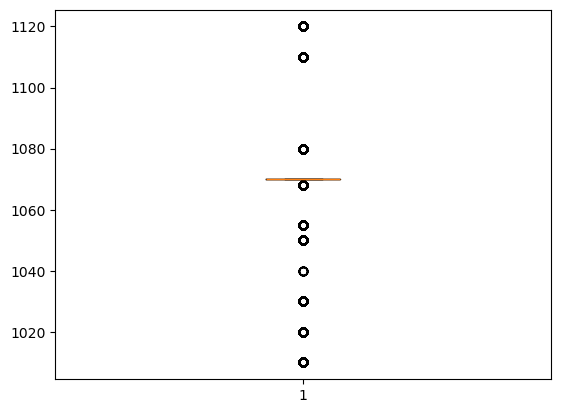

In [15]:
plt.boxplot(df['status'])
plt.show()

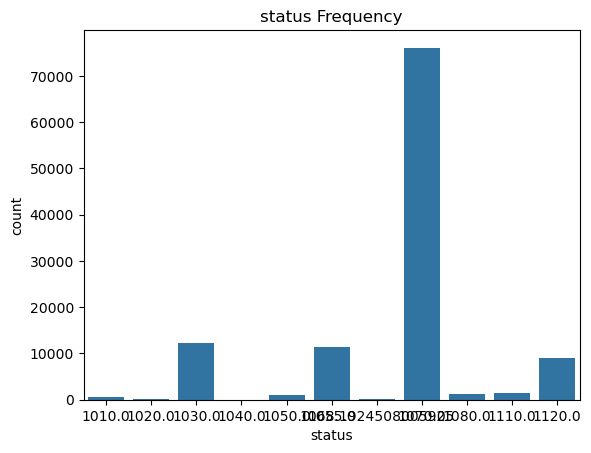

In [16]:
sns.countplot(x='status', data=df)
plt.title("status Frequency")
plt.show()

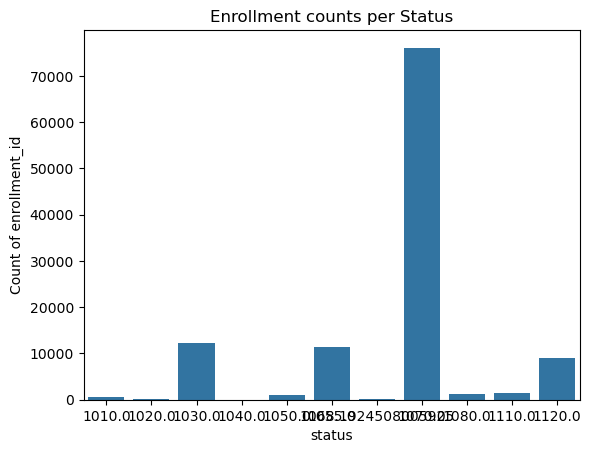

In [17]:
count_df = df.groupby('status')['enrollment_id'].count().reset_index()

sns.barplot(x='status', y='enrollment_id', data=count_df)
plt.title("Enrollment counts per Status")
plt.ylabel('Count of enrollment_id')
plt.show()

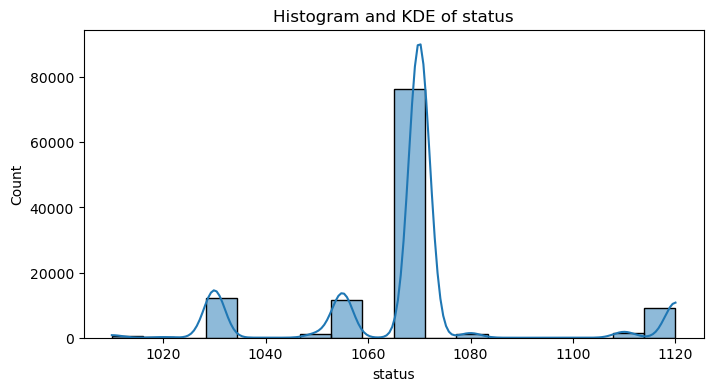

In [18]:
for column in df.select_dtypes(include=['number']).columns:
    plt.figure(figsize=(8,4))
    sns.histplot(df[column], kde=True)
    plt.title(f'Histogram and KDE of {column}')
    plt.show()

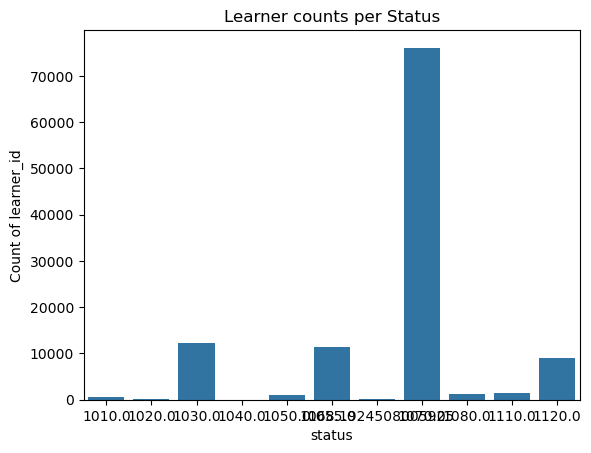

In [22]:
count_df = df.groupby('status')['learner_id'].count().reset_index()

sns.barplot(x='status', y='learner_id', data=count_df)
plt.title("Learner counts per Status")
plt.ylabel('Count of learner_id')
plt.show()

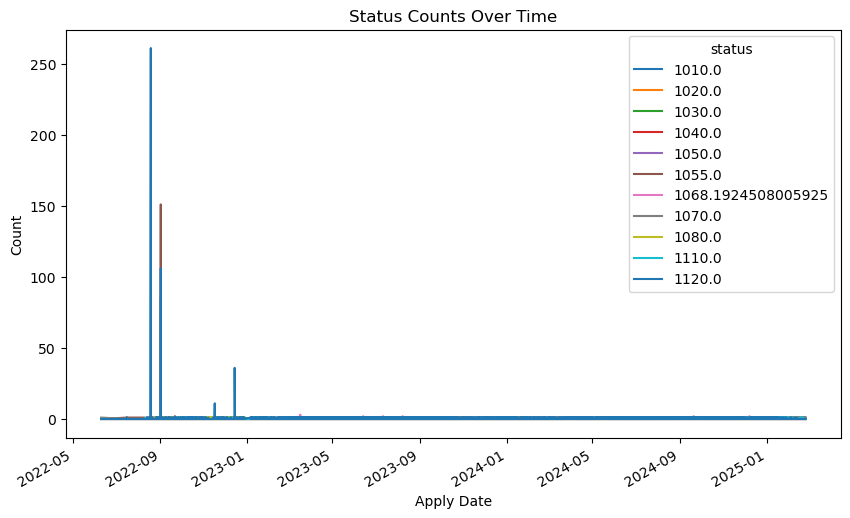

In [25]:
status_counts = df.groupby(['apply_date', 'status']).size().unstack(fill_value=0)

status_counts.plot(kind='line', figsize=(10,6))
plt.xlabel('Apply Date')
plt.ylabel('Count')
plt.title('Status Counts Over Time')
plt.show()

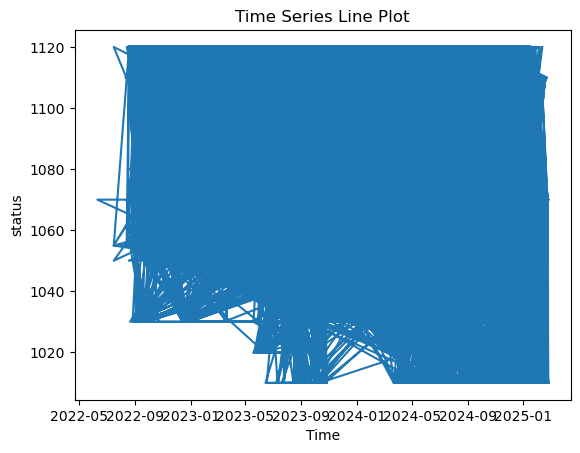

In [26]:
plt.plot(df['apply_date'], df['status'])
plt.xlabel('Time')
plt.ylabel('status')
plt.title('Time Series Line Plot')
plt.show()

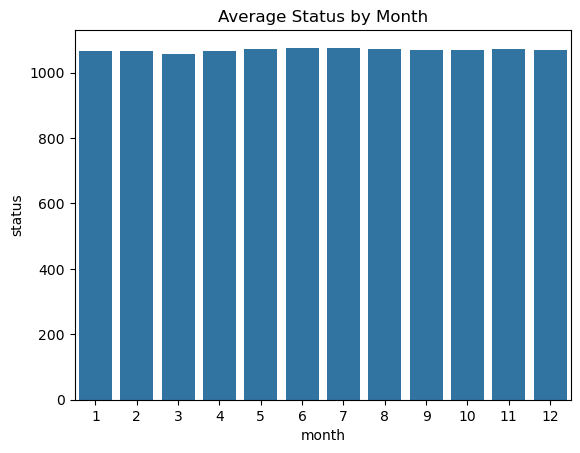

In [28]:
sns.barplot(x='month', y='status', data=monthly_avg)
plt.title('Average Status by Month')
plt.show()

In [29]:
print(df.describe(include='all'))

       enrollment_id                              learner_id assigned_cohort  \
count         113602                                  113602          113602   
unique         57966                                     187             576   
top     Opportunity#  Opportunity#000000000GWQAXC5X45C2MHJ28         Unknown   
freq             186                                   10772           13318   
mean             NaN                                     NaN             NaN   
min              NaN                                     NaN             NaN   
25%              NaN                                     NaN             NaN   
50%              NaN                                     NaN             NaN   
75%              NaN                                     NaN             NaN   
max              NaN                                     NaN             NaN   
std              NaN                                     NaN             NaN   

                                 apply_

In [31]:
for col in df.select_dtypes(include=['object', 'category', 'datetime']).columns:
    print(f"Value counts for {col}:")
    print(df[col].value_counts(dropna=False))  # include NaNs in counts
    print()

Value counts for enrollment_id:
enrollment_id
Opportunity#                                    186
Learner#243da79d-ba07-43aa-af7c-1de782937199     70
Learner#882d1a22-5a56-4abc-ba65-9e537f34e02c     64
Learner#f386224b-4b64-4d70-a6c5-8d90e3653925     61
Learner#1b882553-aaeb-4b2b-aace-36f0543d730e     58
                                               ... 
Learner#e5c6abc4-4606-4cba-8239-ee7f0cad45dc      1
Learner#e65efc66-309c-4119-a4cb-3f21c6265c47      1
Learner#e6b0fd5a-d70d-4916-a3bf-6f9b68289dac      1
Learner#e6b712f6-13d8-42a6-8359-f23664e955f7      1
Learner#8f71095a-ebe7-41f0-a1a6-5aabc35c322e      1
Name: count, Length: 57966, dtype: int64

Value counts for learner_id:
learner_id
Opportunity#000000000GWQAXC5X45C2MHJ28    10772
Opportunity#000000000GHB4N83QX9KJM48K2     9026
Opportunity#000000000GN2A0AY7XK8C5FZPP     6345
Opportunity#0000000010SAZXDAE05AN2CGAN     6102
Opportunity#0000000010GG17ZMAP4TWQVBGQ     5704
                                          ...  
Opportunity#

In [35]:
# 1. Summary of Numeric Columns
print("### Numeric Data Summary ###")
print(df.describe())
print("\n")

### Numeric Data Summary ###
              status          month
count  113602.000000  113602.000000
mean     1068.192451       6.089426
std        21.010305       3.594805
min      1010.000000       1.000000
25%      1070.000000       3.000000
50%      1070.000000       6.000000
75%      1070.000000       9.000000
max      1120.000000      12.000000




In [36]:
# 2. Summary of Categorical and Datetime Columns
for col in df.select_dtypes(include=['object', 'category', 'datetime']).columns:
    print(f"Value counts for {col}:")
    print(df[col].value_counts(dropna=False))
    print("\n")

Value counts for enrollment_id:
enrollment_id
Opportunity#                                    186
Learner#243da79d-ba07-43aa-af7c-1de782937199     70
Learner#882d1a22-5a56-4abc-ba65-9e537f34e02c     64
Learner#f386224b-4b64-4d70-a6c5-8d90e3653925     61
Learner#1b882553-aaeb-4b2b-aace-36f0543d730e     58
                                               ... 
Learner#e5c6abc4-4606-4cba-8239-ee7f0cad45dc      1
Learner#e65efc66-309c-4119-a4cb-3f21c6265c47      1
Learner#e6b0fd5a-d70d-4916-a3bf-6f9b68289dac      1
Learner#e6b712f6-13d8-42a6-8359-f23664e955f7      1
Learner#8f71095a-ebe7-41f0-a1a6-5aabc35c322e      1
Name: count, Length: 57966, dtype: int64


Value counts for learner_id:
learner_id
Opportunity#000000000GWQAXC5X45C2MHJ28    10772
Opportunity#000000000GHB4N83QX9KJM48K2     9026
Opportunity#000000000GN2A0AY7XK8C5FZPP     6345
Opportunity#0000000010SAZXDAE05AN2CGAN     6102
Opportunity#0000000010GG17ZMAP4TWQVBGQ     5704
                                          ...  
Opportunity

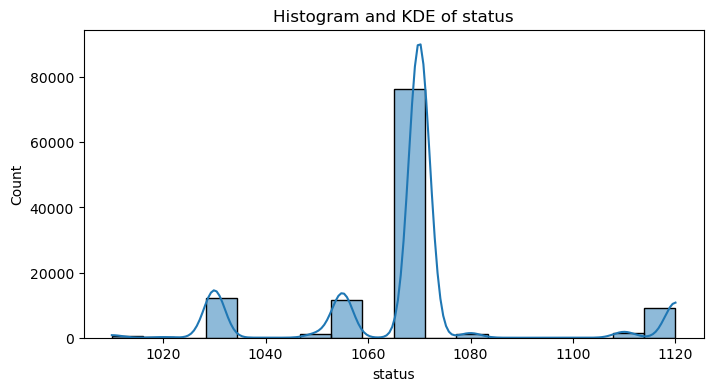

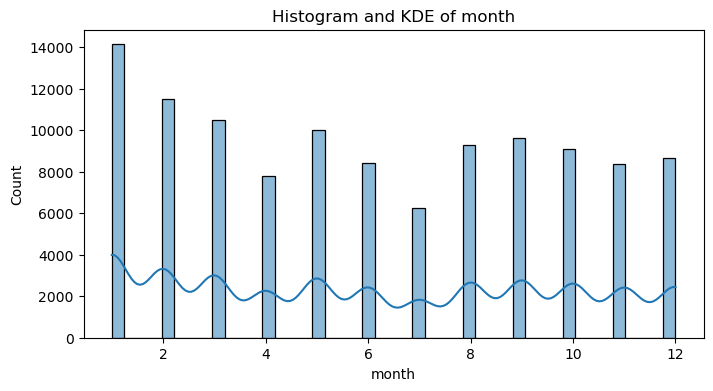

In [37]:
# 3. Visualizations for Numeric Columns
for col in df.select_dtypes(include=['number']).columns:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Histogram and KDE of {col}')
    plt.show()

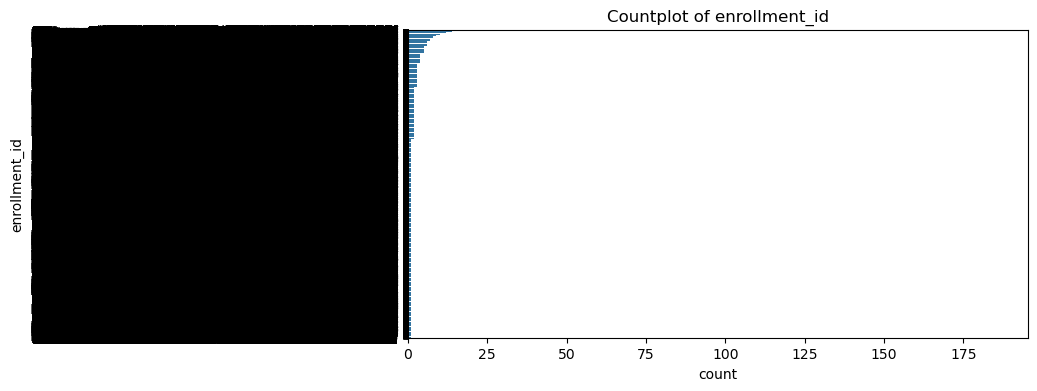

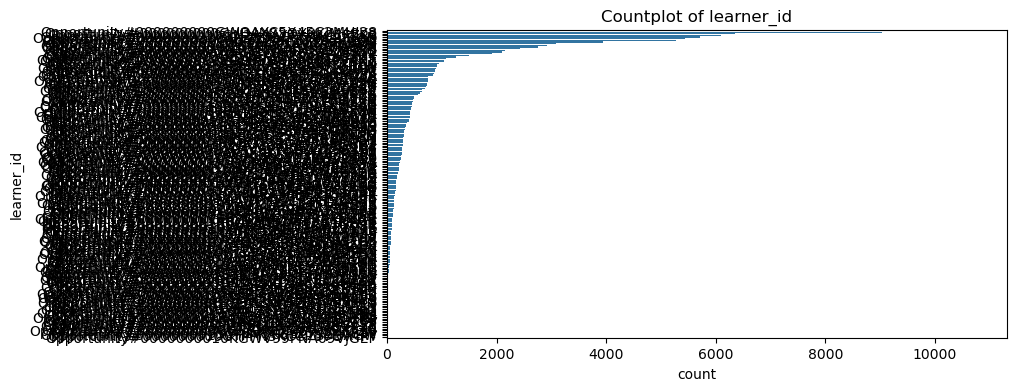

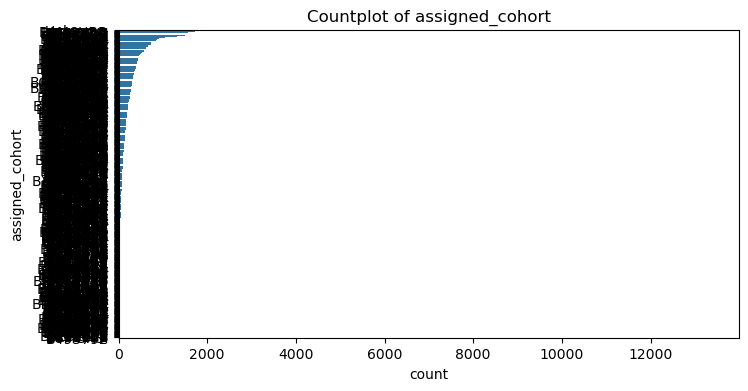

In [38]:
for col in df.select_dtypes(include=['object', 'category']).columns:
    plt.figure(figsize=(8,4))
    sns.countplot(y=col, data=df, order=df[col].value_counts().index)
    plt.title(f'Countplot of {col}')
    plt.show()

In [39]:
# 5. Time Series Visualization
datetime_cols = df.select_dtypes(include=['datetime']).columns
numeric_cols = df.select_dtypes(include=['number']).columns

if len(datetime_cols) > 0 and len(numeric_cols) > 0:
    for dt_col in datetime_cols:
        for num_col in numeric_cols:
            plt.figure(figsize=(10,5))
            sns.lineplot(x=dt_col, y=num_col, data=df)
            plt.title(f'Time Series of {num_col} over {dt_col}')
            plt.xlabel(dt_col)
            plt.ylabel(num_col)
            plt.show()

In [40]:
# 6. Summary
print("Report generation complete! Customize the prints and plots as needed.")

Report generation complete! Customize the prints and plots as needed.


In [41]:
import os
print(os.getcwd())

c:\Users\user\OneDrive\Desktop\python programming
